# Filtering out non-PROTAC molecules

**Goal:** flag input molecules that are *not PROTACs* (bad SMILES, out-of-scope chemistry, single
ligands, random database junk) so they can be excluded before downstream use.

**What changed vs v1 (`analyze_splits.ipynb`), and why:**

1. **"non-PROTAC" is a property of the *input molecule*, not of the split.** v1 scored rows mostly on
   *linker / E3 / POI* descriptors, but those fragments only exist *because of the predicted split*
   (`default_pred_n0`). Scoring molecule identity on them conflates "is this a PROTAC?" with "did the
   splitter do a good job?". v2 makes the non-PROTAC decision on **whole-molecule (`protac_*`)
   descriptors only** — computed on the intact SMILES, independent of any split. Fragment
   distributions are still plotted, but only as context.
2. **Primary signal = the defining feature of a PROTAC: does it contain a known E3-ligand chemotype?**
   Computed directly on the intact molecule by substructure-matching the repo's own curated
   representative E3 ligands (`DEFAULT_REPRESENTATIVE_E3S`) plus two textbook recruiter cores
   (CRBN glutarimide, VHL 4-hydroxyproline). High precision for "IS a PROTAC"; lower recall (novel
   E3s), so E3-absence is combined with a structural-anomaly signal rather than used alone.

In [105]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('..'))  # make the repo importable when running from notebooks/
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

sns.set_style('whitegrid')
RANDOM_STATE = 0

# Point to shared CSV file
df = pd.read_csv('../smiles_with_splits_and_descriptors.csv', low_memory=False).reset_index(drop=True)
df.to_csv('../smiles_with_splits_and_descriptors.csv', index=False)
print(f'{len(df):,} molecules x {df.shape[1]} columns')
df.head(3)

# Legacy code
# df = pd.read_csv('../tack_smiles_split.analysis.csv', low_memory=False)
# db_source_df = pd.read_csv('../tack_smiles.csv')

# n_before = len(df)
# df = pd.merge(df, db_source_df, how='left', on='SMILES')
# assert len(df) == n_before, (
#     f'merge changed row count {n_before} -> {len(df)}; a duplicate SMILES in db_source_df would '
#     'silently inflate rows (v1 had no such guard).'
# )

24,812 molecules x 163 columns


,SMILES,default_pred_n0,model_name,heuristic_params,protac_heavy_atoms,protac_mw,protac_graph_diameter,protac_num_bonds,protac_num_rotatable_bonds,protac_frac_rotatable_bonds,...,reason_leaving_group,reason_linker_branchy,reason_linker_too_short,reason_low_confidence,reason_method_disagreement,reason_poi_linker_leak,reason_poi_low_similarity,reason_poi_out_of_range,reason_unstable,Database
0,CCC(C)(C)C(=O)C(=O)N1CCCC[C@H]1C(=O)O[C@H](CCc...,O=C(CCl)[*:2].O=C(CO[*:1])NCCCOCCOCCOCCCN(C(C(...,XGBoost,NaN,79,1154.6,38,83,34,0.430,...,True,True,False,True,True,False,False,False,True,PROTAC-DB
1,O=C(COc1ccc2c(c1)CCCN2C(=O)CCl)NCCOCCOCCOCCOCC...,O=C(CCl)N1CCCc2cc([*:2])ccc21.O=C(CO[*:2])NCCO...,Heuristic,"betweenness_threshold=0.3,use_capacity_weight=...",82,1205.6,50,88,32,0.390,...,True,True,False,True,True,False,True,False,True,TPDdb
2,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OCC(=O)NCCCCCCNC(...,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OCC(=O)[*:2].CC(C...,Heuristic,"betweenness_threshold=0.5,use_capacity_weight=...",63,889.1,32,64,20,0.317,...,True,True,False,True,False,False,True,True,True,TPDdb


In [106]:
from protac_splitter.chemoinformatics import canonize_smiles

tack = pd.read_csv('../tack_v2_with_splits_and_predictions.csv')[['Reference', 'SMILES']].drop_duplicates()
# df = pd.merge(df, tack, how='left', on='SMILES')
# print(df['Reference'].nunique())

protacdb = pd.read_csv('../data/PROTAC-DB.csv').rename(columns={'Article DOI': 'Reference', 'Smiles': 'SMILES'})[['SMILES', 'Reference']]
protacdb['SMILES'] = protacdb['SMILES'].apply(canonize_smiles)

protacpedia = pd.read_csv('../data/PROTAC-Pedia.csv').rename(columns={'Pubmed': 'Reference', 'PROTAC SMILES': 'SMILES'})[['SMILES', 'Reference']]
protacpedia['SMILES'] = protacpedia['SMILES'].apply(canonize_smiles)

tmp = pd.concat([tack, protacdb, protacpedia]).drop_duplicates()

df = pd.merge(df, tmp, how='left', on='SMILES')
print(df['Reference'].nunique())
df.to_csv('../smiles_with_splits_and_descriptors.csv', index=False)

622


## Feature groups

The non-PROTAC decision uses only whole-molecule `protac_*` descriptors (split-independent). The
`e3` / `linker` / `poi` groups are derived from `default_pred_n0` and are kept for distribution
*context* only — they describe split quality, not molecule identity.

In [89]:
def numeric_feature_columns(prefix, df):
    # Numeric, non-boolean, non-constant columns for a given prefix.
    cols = [c for c in df.columns if c.startswith(prefix)]
    cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])]
    cols = [c for c in cols if df[c].nunique(dropna=True) > 1]
    return cols

def drop_correlated(cols, df, threshold=0.98):
    # Greedily drop one of each pair of near-duplicate features (e.g. mw vs heavy_atoms).
    if len(cols) < 2:
        return cols
    corr = df[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return [c for c in cols if c not in to_drop]

feature_groups = {
    'protac': drop_correlated(numeric_feature_columns('protac_', df), df),
    'e3':     drop_correlated(numeric_feature_columns('e3_', df), df),
    'linker': drop_correlated(numeric_feature_columns('linker_', df), df),
    'poi':    drop_correlated(numeric_feature_columns('poi_', df), df),
}
protac_features = feature_groups['protac']
for k, v in feature_groups.items():
    print(f'{k:8s} ({len(v):2d}): {v}')

protac   (17): ['protac_heavy_atoms', 'protac_graph_diameter', 'protac_num_rotatable_bonds', 'protac_frac_rotatable_bonds', 'protac_frac_csp3', 'protac_tpsa', 'protac_logp', 'protac_num_stereocenters', 'protac_num_rings', 'protac_num_aromatic_rings', 'protac_num_aliphatic_rings', 'protac_num_saturated_rings', 'protac_max_ring_size', 'protac_num_macrocycles', 'protac_num_spiro_atoms', 'protac_num_bridgehead_atoms', 'protac_num_brenk_hits']
e3       (19): ['e3_heavy_atoms', 'e3_graph_diameter', 'e3_num_rotatable_bonds', 'e3_frac_rotatable_bonds', 'e3_frac_csp3', 'e3_tpsa', 'e3_logp', 'e3_num_stereocenters', 'e3_num_rings', 'e3_num_aromatic_rings', 'e3_num_aliphatic_rings', 'e3_num_saturated_rings', 'e3_max_ring_size', 'e3_num_macrocycles', 'e3_num_spiro_atoms', 'e3_num_bridgehead_atoms', 'e3_num_brenk_hits', 'e3_attachment_chain_length', 'e3_sim_to_known_e3']
linker   (20): ['linker_heavy_atoms', 'linker_graph_diameter', 'linker_num_rotatable_bonds', 'linker_frac_rotatable_bonds', 'linke

## Distribution overview

Small-multiple histograms (boxplots hide multimodality; used later for *group* comparisons). The
whole-PROTAC panel is the one that feeds the filter; the linker panel is split-derived context.

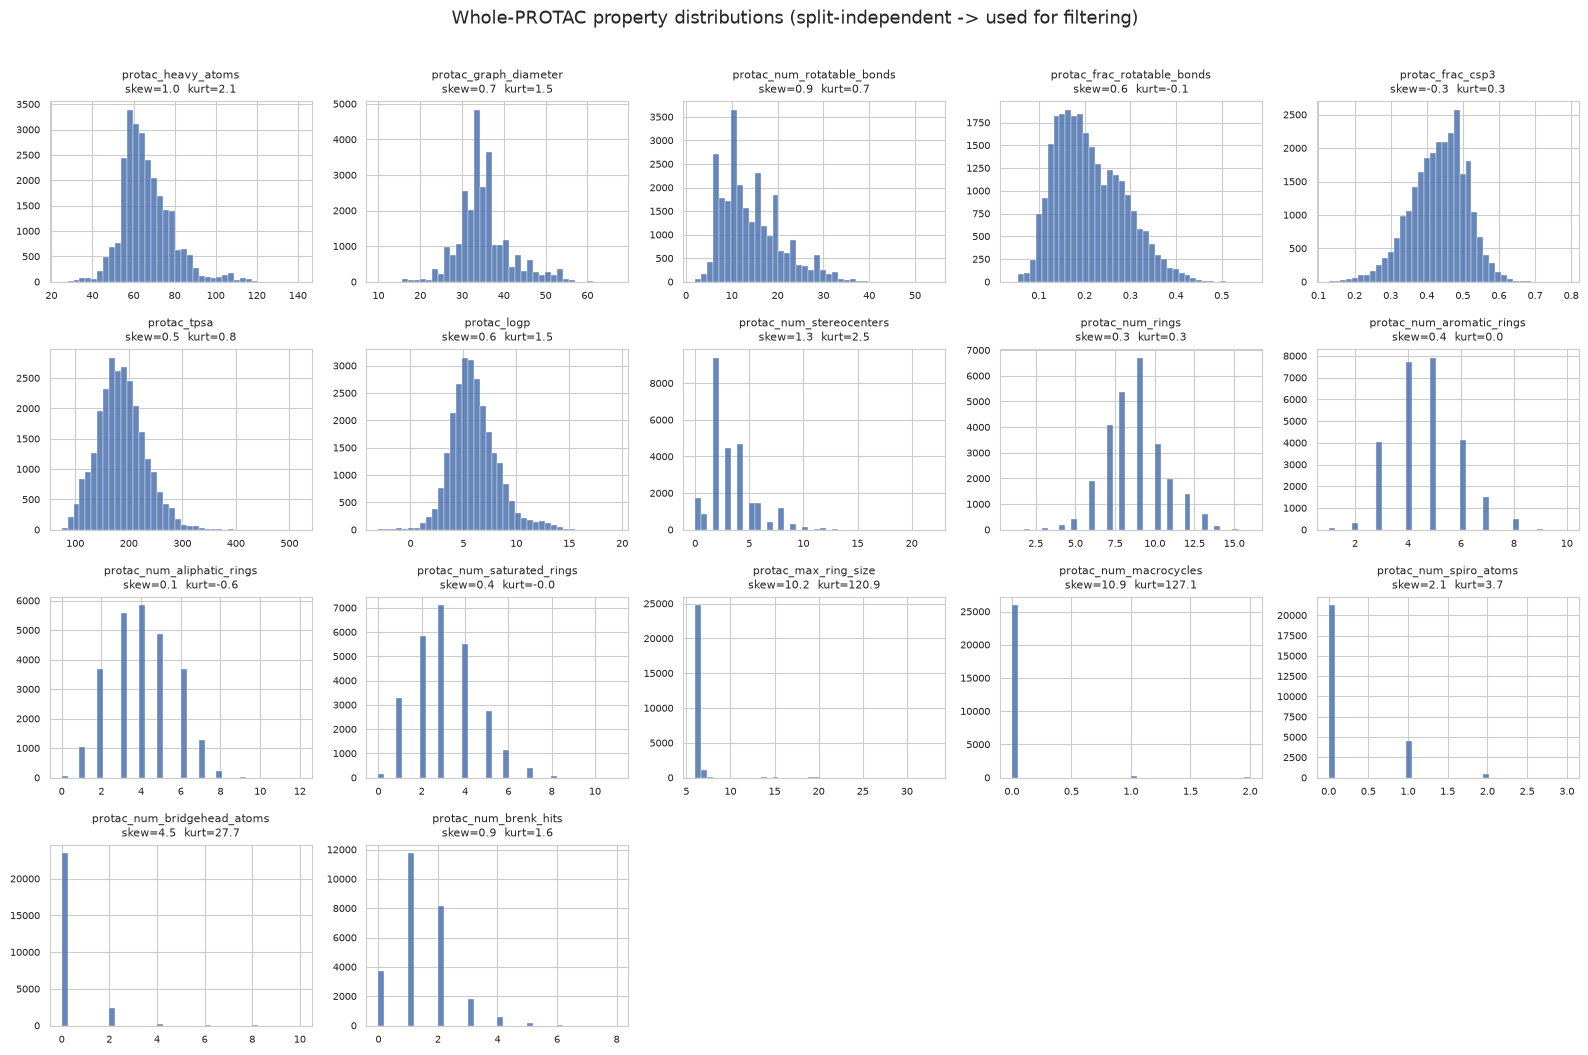

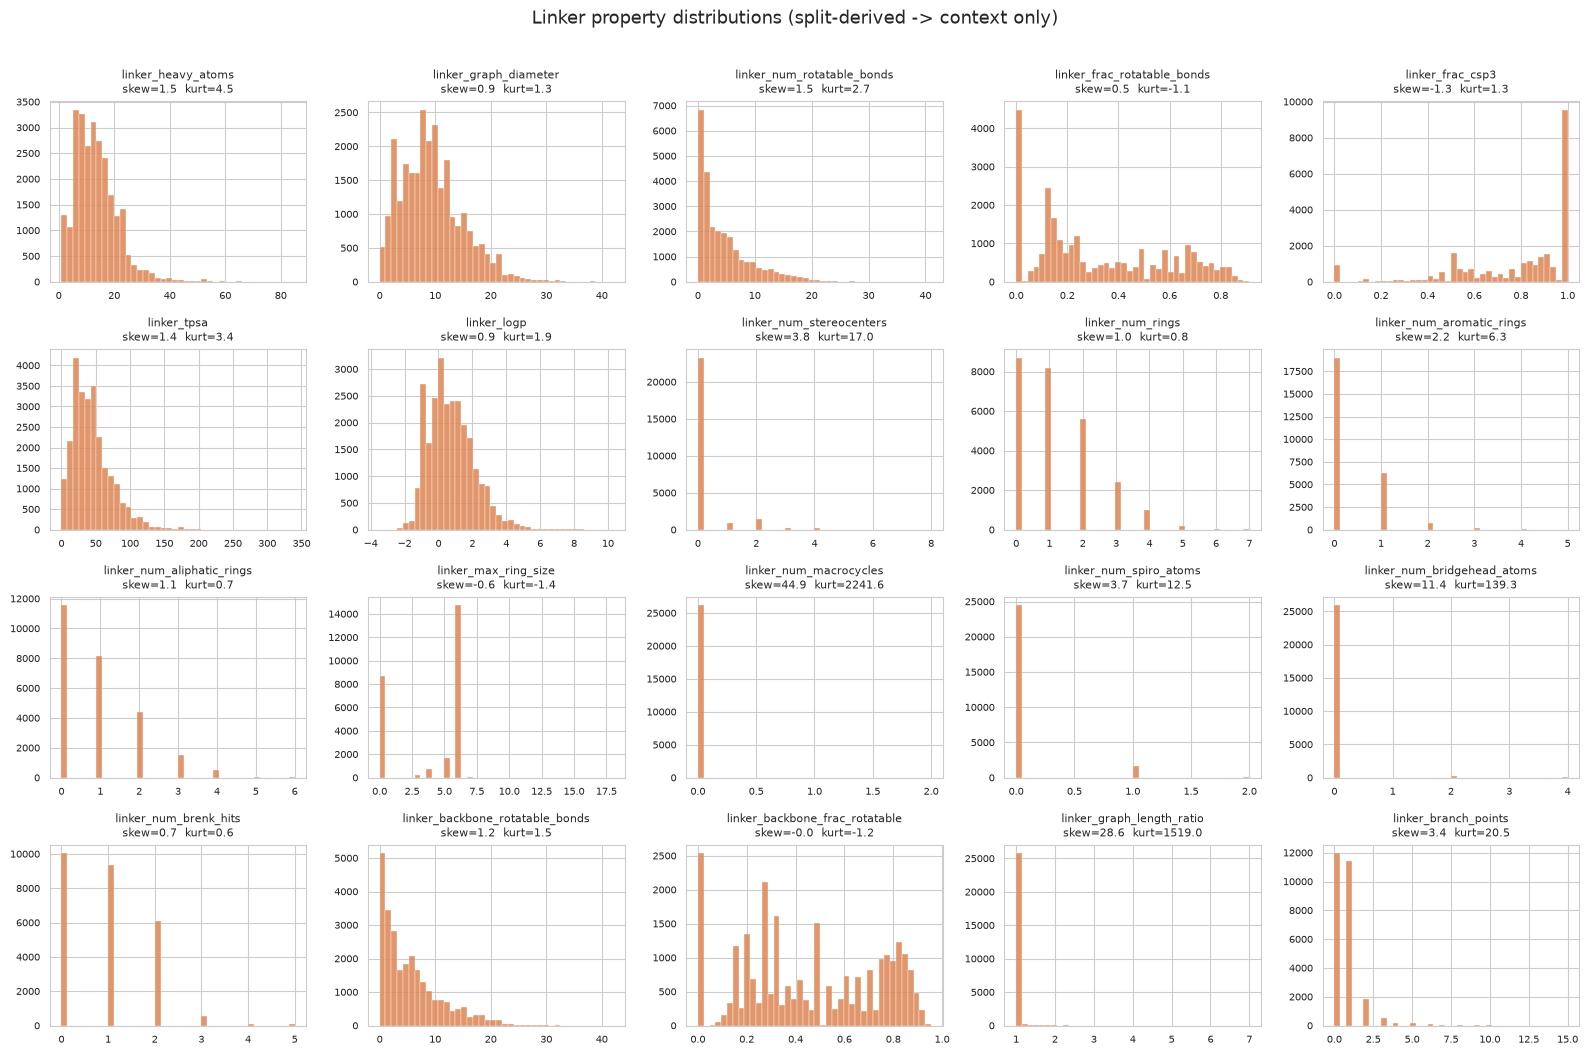

In [90]:
def plot_distribution_grid(cols, df, title, ncols=5, color='#4C72B0'):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, cols):
        vals = df[col].dropna()
        ax.hist(vals, bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{col}\nskew={stats.skew(vals):.1f}  kurt={stats.kurtosis(vals):.1f}', fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

plot_distribution_grid(protac_features, df, 'Whole-PROTAC property distributions (split-independent -> used for filtering)')
plot_distribution_grid(feature_groups['linker'], df, 'Linker property distributions (split-derived -> context only)', color='#DD8452')

In [91]:
def skew_kurt_table(feature_groups, df):
    rows = []
    for grp, cols in feature_groups.items():
        for c in cols:
            vals = df[c].dropna()
            rows.append({'group': grp, 'feature': c,
                         'skew': stats.skew(vals), 'excess_kurtosis': stats.kurtosis(vals),
                         'n_missing': int(df[c].isna().sum())})
    return pd.DataFrame(rows).sort_values('excess_kurtosis', ascending=False).reset_index(drop=True)

sk_table = skew_kurt_table(feature_groups, df)
print('Most leptokurtic features (percentile-flagged, not z-scored, in the rule-based signal below):')
sk_table.head(12)

Most leptokurtic features (percentile-flagged, not z-scored, in the rule-based signal below):


,group,feature,skew,excess_kurtosis,n_missing
0,e3,e3_num_macrocycles,65.914087,4342.666897,122
1,e3,e3_max_ring_size,42.221802,2981.468298,122
2,linker,linker_num_macrocycles,44.883546,2241.621374,49
3,linker,linker_graph_length_ratio,28.557417,1518.956340,0
4,poi,poi_sim_to_known_e3,11.372472,238.576084,1197
5,e3,e3_num_bridgehead_atoms,14.212438,209.860345,122
6,linker,linker_num_bridgehead_atoms,11.406509,139.301410,49
7,poi,poi_num_macrocycles,11.050219,129.487844,1197
8,protac,protac_num_macrocycles,10.924783,127.142606,0
9,protac,protac_max_ring_size,10.228870,120.932872,0


## Filter 1 — known E3-ligand containment (split-independent, primary)

The near-definition of a PROTAC is that it contains an **E3-ligase recruiter**. We test this on the
**intact** molecule (no split needed) by substructure-matching:

- the repo's curated **representative E3 ligands** (`DEFAULT_REPRESENTATIVE_E3S`), each capped at its
  `[*:2]` attachment so it matches wherever that ligand sits inside a PROTAC; plus
- two **textbook recruiter cores** as unambiguous SMARTS — CRBN **glutarimide**
  (`O=C1CCCC(=O)N1`, thalidomide/pomalidomide/lenalidomide) and VHL **4-hydroxyproline**
  (`[OX2H1]C1C[CH](NC1)C(=O)N`, VH032-type) — which catch chemotype variants a specific
  representative would miss.

`has_known_e3` is **high precision** for "is a PROTAC" but **lower recall**: a molecule with a novel
or under-represented E3 ligand can be a real PROTAC yet match nothing. So E3-absence is treated as
*evidence*, combined below with a structural-anomaly signal — never as a lone hard filter.

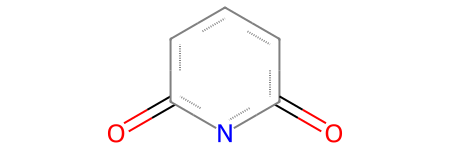

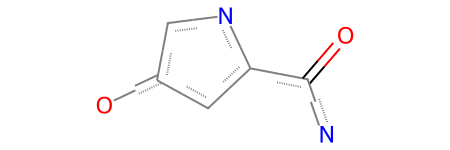

32 curated E3 queries, 49 curated warhead queries
contains a known E3 ligand chemotype:  88.4%
contains a known warhead chemotype:    22.4%
NO known E3 ligand (candidate non-PROTAC / novel E3): 11.6% (3028 rows)

E3 evidence breakdown:
e3_evidence
CRBN;e3_curated_representative                                  11720
VHL;wh_curated_representative                                    3849
CRBN                                                             3289
none                                                             2799
VHL                                                              2125
CRBN;e3_curated_representative;wh_curated_representative         1140
VHL;e3_curated_representative;wh_curated_representative           303
e3_curated_representative                                         288
wh_curated_representative                                         229
CRBN;wh_curated_representative                                    187
VHL;e3_curated_representative                       

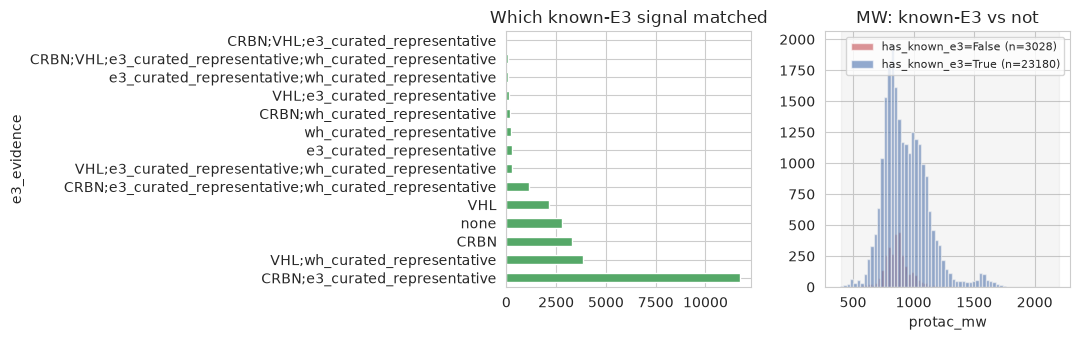

In [92]:
from protac_splitter.graphs.clustering import (
    DEFAULT_REPRESENTATIVE_E3S,
    DEFAULT_REPRESENTATIVE_WHS,
)
from protac_splitter.chemoinformatics import remove_dummy_atoms

def capped_query(smi):
    # Curated ligand SMILES (with a [*:n] attachment) -> substructure query: remove the dummy so the
    # ligand matches where it sits inside an intact PROTAC (attachment atom bonded to the linker).
    capped = remove_dummy_atoms(smi, canonical=True)
    return Chem.MolFromSmiles(capped) if capped else None

E3_QUERIES = [q for q in (capped_query(s) for s in DEFAULT_REPRESENTATIVE_E3S) if q is not None]
WH_QUERIES = [q for q in (capped_query(s) for s in DEFAULT_REPRESENTATIVE_WHS) if q is not None]
CRBN_GLUTARIMIDE   = Chem.MolFromSmarts('O=C1CCCC(=O)N1')
VHL_HYDROXYPROLINE = Chem.MolFromSmarts('[OX2H1]C1C[CH](NC1)C(=O)N')

display(CRBN_GLUTARIMIDE)
display(VHL_HYDROXYPROLINE)

assert CRBN_GLUTARIMIDE is not None and VHL_HYDROXYPROLINE is not None
print(f'{len(E3_QUERIES)} curated E3 queries, {len(WH_QUERIES)} curated warhead queries')

rows = []
for smi, e3_sim, wh_sim in zip(df['SMILES'], df['e3_sim_to_known_e3'], df['poi_sim_to_known_e3']):
    m = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if m is None:
        rows.append((False, 'unparseable', False)); continue

    # Check if E3 ligand is similar to known structures
    hit_crbn = m.HasSubstructMatch(CRBN_GLUTARIMIDE)
    hit_vhl  = m.HasSubstructMatch(VHL_HYDROXYPROLINE)
    hit_rep  = any(m.HasSubstructMatch(q) for q in E3_QUERIES) or e3_sim > 0.80
    # Concatenate any of the above if it was a hit, 'none' otherwise
    evid = ';'.join(n for n, h in [('CRBN', hit_crbn), ('VHL', hit_vhl), ('e3_curated_representative', hit_rep)] if h) or 'none'

    # Check if warhead is similar to known structures
    hit_wh = any(m.HasSubstructMatch(q) for q in WH_QUERIES) or wh_sim > 0.80
    if hit_wh:
        evid = evid + ';wh_curated_representative' if evid != 'none' else 'wh_curated_representative'

    rows.append((hit_crbn or hit_vhl or hit_rep, evid, hit_wh))

df[['has_known_e3', 'e3_evidence', 'has_known_wh']] = pd.DataFrame(rows, index=df.index)

print(f'contains a known E3 ligand chemotype: {df["has_known_e3"].mean():6.1%}')
print(f'contains a known warhead chemotype:   {df["has_known_wh"].mean():6.1%}')
print(f'NO known E3 ligand (candidate non-PROTAC / novel E3): {(~df["has_known_e3"]).mean():.1%} '
      f'({int((~df["has_known_e3"]).sum())} rows)')
print('\nE3 evidence breakdown:')
print(df['e3_evidence'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df['e3_evidence'].value_counts().plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Which known-E3 signal matched')
for lbl, sub in df.groupby('has_known_e3'):
    axes[1].hist(sub['protac_mw'].dropna(), bins=60, alpha=0.6,
                 color='#4C72B0' if lbl else '#C44E52', label=f'has_known_e3={lbl} (n={len(sub)})')
axes[1].axvspan(400, 2200, color='grey', alpha=0.08)
axes[1].set_xlabel('protac_mw'); axes[1].set_title('MW: known-E3 vs not'); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

In [93]:
from rdkit import Chem

def to_mol(smi):
    return Chem.MolFromSmiles(smi)

def plot_df(df, max_displays: int = 20):
    print(f"Dataframe length: {len(df):,}")
    for i, row in df.reset_index().iterrows():
        print('-' * 80)
        print(row['SMILES'])
        print(row['default_pred_n0'])
        display(to_mol(row['SMILES']))
        display(to_mol(row['default_pred_n0']))
        if i > max_displays:
            break

# Uncomment to visualize filtered PROTACs
# plot_df(df[~df['has_known_e3']])

## Filter 2 — whole-molecule sanity rules + univariate extremeness

Two univariate pieces, both on the **intact PROTAC only**:

- **Per-feature extremeness** on `protac_*` descriptors. Heavy-tailed (high-kurtosis) features are
  flagged by extreme percentile (>99.5th/<0.5th); the rest by a robust median/MAD z-score
  (`|z|>3.5`) — mean/std z-scores are unstable on the leptokurtic features from the table above.
- **Hard chemistry rules** a distributional test can't encode. Every rule here is whole-molecule.

rule_based_is_outlier rate: 10.6%


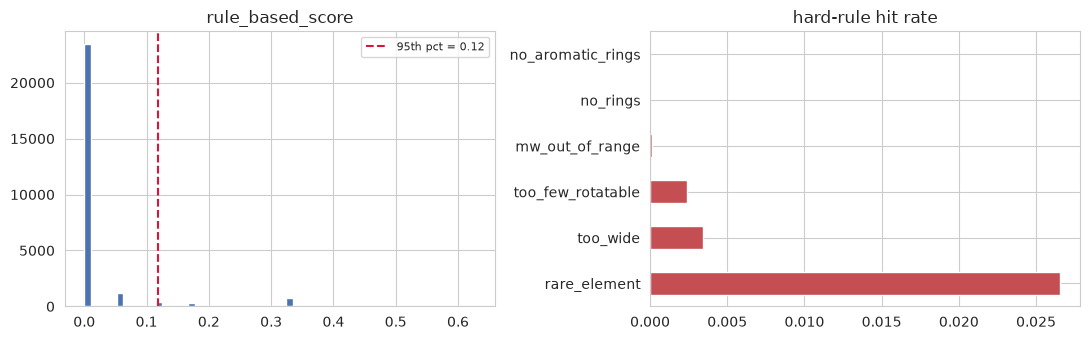

In [94]:
def robust_z(series):
    med = series.median()
    mad = stats.median_abs_deviation(series.dropna(), scale='normal')
    if mad == 0 or np.isnan(mad):
        return pd.Series(0.0, index=series.index)
    return (series - med) / mad

def feature_outlier_flags(cols, df, z_thresh=3.5, kurt_thresh=10.0, pct_thresh=0.995):
    flags = pd.DataFrame(index=df.index)
    for c in cols:
        vals = df[c]
        if abs(stats.kurtosis(vals.dropna())) > kurt_thresh:
            hi, lo = vals.quantile(pct_thresh), vals.quantile(1 - pct_thresh)
            flags[c] = (vals > hi) | (vals < lo)
        else:
            flags[c] = robust_z(vals).abs() > z_thresh
        flags[c] = flags[c].fillna(False)
    return flags

protac_flags = feature_outlier_flags(protac_features, df)
df['rb_protac_outlier_frac'] = protac_flags.mean(axis=1)
df['rb_protac_outlier'] = protac_flags.any(axis=1)

hard_rules = pd.DataFrame(index=df.index)
hard_rules['mw_out_of_range']   = ~df['protac_mw'].between(400, 2200)      # PROTACs are large bifunctionals
hard_rules['no_rings']          = df['protac_num_rings'] == 0              # always has ring systems
hard_rules['no_aromatic_rings'] = df['protac_num_aromatic_rings'] == 0     # both ligands are aromatic-rich
hard_rules['too_few_rotatable'] = df['protac_num_rotatable_bonds'] < 4     # needs a flexible linker
hard_rules['rare_element']      = df['protac_flag_rare_element'].fillna(False).astype(bool)
# NOTE: More rules can be encoded here
hard_rules['too_wide']          = df['protac_graph_diameter'] > 55

# Sum any flagged rule
df['rb_hard_rule_hits'] = hard_rules.sum(axis=1)

# Determine a continuous score for the hard rules
w_stat, w_hard = 1.0, 2.0
df['rule_based_score'] = w_stat * df['rb_protac_outlier_frac'] + w_hard * hard_rules.mean(axis=1)

# Determine outlier based on continuous score
score_thresh = df['rule_based_score'].quantile(0.95)
# df['rule_based_is_outlier'] = (df['rule_based_score'] >= score_thresh) | (df['rb_hard_rule_hits'] > 0)

# Determine outlier if extreme on distribution or non passing a rule
df['rule_based_is_outlier'] = df['rb_protac_outlier'] | (df['rb_hard_rule_hits'] > 0)

print(f'rule_based_is_outlier rate: {df["rule_based_is_outlier"].mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df['rule_based_score'], bins=60, color='#4C72B0')
axes[0].axvline(score_thresh, color='crimson', ls='--', label=f'95th pct = {score_thresh:.2f}')
axes[0].set_title('rule_based_score'); axes[0].legend(fontsize=8)
hard_rules.mean().sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('hard-rule hit rate')
fig.tight_layout(); plt.show()

In [95]:
# plot_df(df[df['rule_based_is_outlier']])

## Filter 3 — multivariate anomaly (IsolationForest on whole-molecule descriptors)

One IsolationForest on the `protac_*` features (not four nested ones), to catch molecules that look
normal on every feature individually but are jointly implausible:

- **PowerTransformer (Yeo–Johnson)** instead of plain StandardScaler, taming the heavy right-skew of
  size/topology features (and handling negative `logp`) so the forest doesn't just flag each
  feature's right tail.
- **`add_indicator=True`** on imputation keeps missingness as a feature instead of median-imputing it
  away

`contamination` is anchored to the rule-based rate, clipped to a plausible `[1%, 10%]` band.

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest

def domain_contamination(mask, lo=0.01, hi=0.10):
    return float(np.clip(mask.mean(), lo, hi))

contamination = domain_contamination(df['rule_based_is_outlier'])
iso_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('varthresh', VarianceThreshold(threshold=1e-6)),
    ('power', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('isoforest', IsolationForest(n_estimators=400, max_samples=0.8, bootstrap=True,
                                  contamination=contamination, random_state=RANDOM_STATE, n_jobs=-1)),
])
X = df[protac_features]
iso_pipe.fit(X)
df['isoforest_protac_is_outlier'] = iso_pipe.predict(X) == -1
df['isoforest_protac_score'] = -iso_pipe.decision_function(X)   # higher = more anomalous
print(f'IsolationForest contamination={contamination:.3f}  n_flagged={int(df["isoforest_protac_is_outlier"].sum())}')

IsolationForest contamination=0.100  n_flagged=2621


In [97]:
# plot_df(df[df['isoforest_protac_is_outlier']])

## Combining the filters

Three **complementary** filters (Jaccard confirms they're not redundant):

- **A. `no_known_e3`** — lacks a known E3 ligand (primary, split-independent chemotype test).
- **B. `rule_based`** — whole-molecule rule/extremeness outlier.
- **C. `IF_protac`** — multivariate anomaly on whole-molecule descriptors.

**Decision:** a molecule is a *probable non-PROTAC* only if it **lacks a known E3 ligand OR looks
structurally off** (B or C). This intersection is far more precise than any single filter —
E3-absence alone also sweeps up genuine novel-E3 PROTACs (which have PROTAC-like MW), and a
descriptor anomaly alone is often just an unusual-but-real PROTAC. `non_protac_rank` (E3 axis
weighted 2×) gives a continuous ranking, and the cut is reported at several thresholds.

cross-filter agreement (# of 3 filters firing):
n_filters
0    19274
1     5509
2     1347
3       78
Name: count, dtype: int64

probable non-PROTAC (no E3 OR anomalous): 26.5% (6934 rows)
threshold sensitivity on non_protac_rank:
  top 10.0%: rank>=0.695 -> 2621 rows
  top 5.0%: rank>=0.746 -> 1311 rows
  top 2.5%: rank>=0.790 -> 656 rows
  top 1.0%: rank>=0.823 -> 263 rows


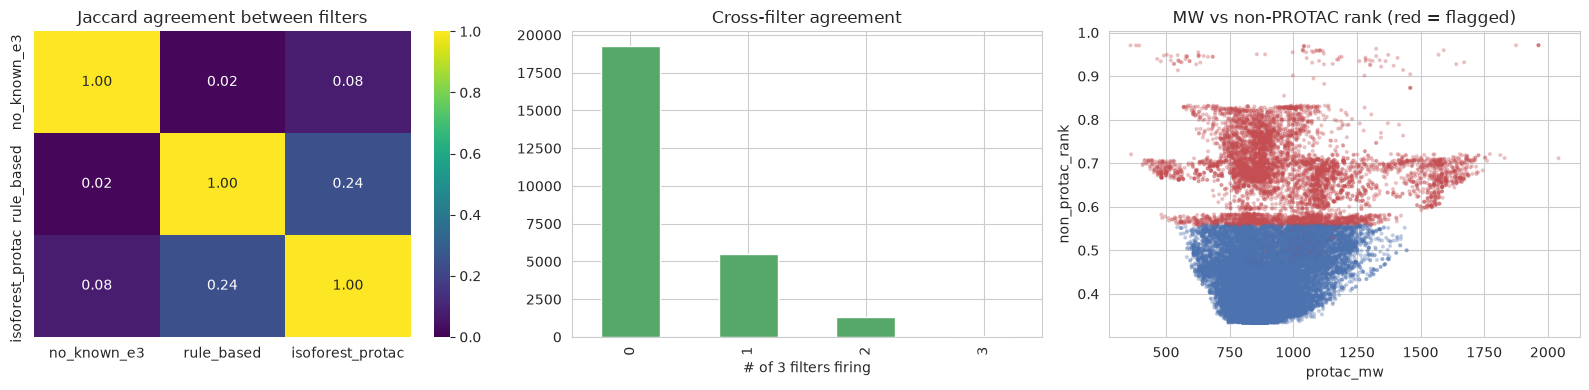

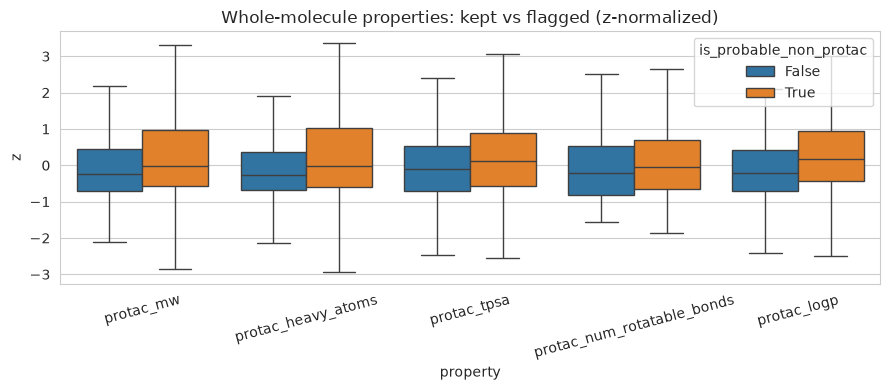

,SMILES,Database,protac_mw,has_known_e3,e3_evidence,n_filters,rule_based_score,isoforest_protac_score,non_protac_rank
7357,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,PROTAC-DB; PROTACpedia,1963.2,False,none,3,0.568627,0.192954,0.970892
7355,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,PROTAC-DB; PROTACpedia,1963.2,False,none,3,0.568627,0.192954,0.970892
7356,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,PROTAC-DB; PROTACpedia,1963.2,False,none,3,0.568627,0.192954,0.970892
7354,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,PROTAC-DB,1875.0,False,none,3,0.568627,0.161134,0.970720
6760,CC(C)[C@@H](C(=O)N1C[C@](C)(O)C[C@H]1C(=O)O)N1...,TPDdb,360.4,False,none,3,0.509804,0.211947,0.970529
331,O=C(NC1CCNCC1)c1n[nH]cc1NC(=O)c1c(Cl)cccc1Cl,PROTACpedia,382.3,False,none,3,0.509804,0.199938,0.970491
1796,CCC(=O)N1CCC(C(=O)Nc2ncc(SCc3ncc(C)o3)s2)CC1,TPDdb,394.5,False,none,3,0.509804,0.161982,0.970310
7372,COc1cc(N2CCC(CN3CC[C@@H](c4ccc5c(N6CCC(=O)NC6=...,TPDdb,1041.9,False,none,3,0.509804,0.113470,0.969132
7309,COc1cc(N2CCC(CN3CC[C@H](c4ccc5c(N6CCC(=O)NC6=O...,TPDdb,1041.9,False,none,3,0.509804,0.113470,0.969132
7438,COc1cc(N2CCC(CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(...,TPDdb,1059.9,False,none,3,0.509804,0.099310,0.968278


In [98]:
from scipy.stats import rankdata

df['flag_no_known_e3'] = ~df['has_known_e3']
df['flag_rule']        = df['rule_based_is_outlier']
df['flag_isoforest']   = df['isoforest_protac_is_outlier']

flag_matrix = pd.DataFrame({'no_known_e3': df['flag_no_known_e3'],
                            'rule_based':  df['flag_rule'],
                            'isoforest_protac':   df['flag_isoforest']})
df['n_filters'] = flag_matrix.sum(axis=1)

score_cols = {'no_known_e3': df['flag_no_known_e3'].astype(float),
              'rule_based':  df['rule_based_score'],
              'isoforest_protac':   df['isoforest_protac_score']}
weights = {'no_known_e3': 2.0, 'rule_based': 1.0, 'isoforest_protac': 1.0}
ranks = pd.DataFrame({k: rankdata(v) / len(v) for k, v in score_cols.items()})
df['non_protac_rank'] = (ranks * pd.Series(weights)).sum(axis=1) / sum(weights.values())

# NOTE: Currently modified to all OR: outlier if weird E3 or structurally off
df['is_probable_non_protac'] = df['flag_no_known_e3'] | (df['flag_rule'] | df['flag_isoforest'])
df['is_good_quality'] = ~df['is_probable_non_protac']

print('cross-filter agreement (# of 3 filters firing):')
print(df['n_filters'].value_counts().sort_index())
print(f'\nprobable non-PROTAC (no E3 OR anomalous): {df["is_probable_non_protac"].mean():.1%} '
      f'({int(df["is_probable_non_protac"].sum())} rows)')
print('threshold sensitivity on non_protac_rank:')
for q in [0.90, 0.95, 0.975, 0.99]:
    t = df['non_protac_rank'].quantile(q)
    print(f'  top {1 - q:4.1%}: rank>={t:.3f} -> {int((df["non_protac_rank"] >= t).sum())} rows')

def jaccard(a, b):
    u = (a | b).sum()
    return (a & b).sum() / u if u else np.nan
names = list(flag_matrix.columns)
jac = pd.DataFrame([[jaccard(flag_matrix[a], flag_matrix[b]) for b in names] for a in names],
                   index=names, columns=names)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(jac, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Jaccard agreement between filters')
df['n_filters'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_xlabel('# of 3 filters firing'); axes[1].set_title('Cross-filter agreement')
axes[2].scatter(df['protac_mw'], df['non_protac_rank'], s=4, alpha=0.25,
                c=np.where(df['is_probable_non_protac'], '#C44E52', '#4C72B0'))
axes[2].set_xlabel('protac_mw'); axes[2].set_ylabel('non_protac_rank')
axes[2].set_title('MW vs non-PROTAC rank (red = flagged)')
fig.tight_layout(); plt.show()

key_props = ['protac_mw', 'protac_heavy_atoms', 'protac_tpsa', 'protac_num_rotatable_bonds', 'protac_logp']
pdf = df[key_props + ['is_probable_non_protac']].copy()
for c in key_props:
    pdf[c] = (pdf[c] - pdf[c].mean()) / pdf[c].std()
pdf = pdf.melt(id_vars='is_probable_non_protac', var_name='property', value_name='z')
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=pdf, x='property', y='z', hue='is_probable_non_protac', ax=ax, showfliers=False)
ax.set_title('Whole-molecule properties: kept vs flagged (z-normalized)')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

display(df.sort_values('non_protac_rank', ascending=False)[
    ['SMILES', 'Database', 'protac_mw', 'has_known_e3', 'e3_evidence', 'n_filters',
     'rule_based_score', 'isoforest_protac_score', 'non_protac_rank']].head(20))

## Spot-check: highest-ranked probable non-PROTACs

Rendered intact molecule (what we judge) plus its split (`default_pred_n0`, context only). This is
the set to eyeball before committing to a hard filter.

6934 probable non-PROTACs; showing the 20 highest-ranked (most suspect):
[PROTAC-DB; PROTACpedia] MW=1963.2  e3_evidence=none  n_filters=3  rank=0.971
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


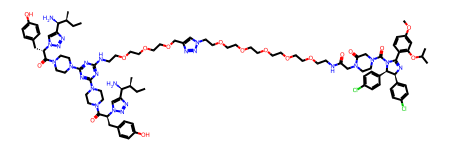

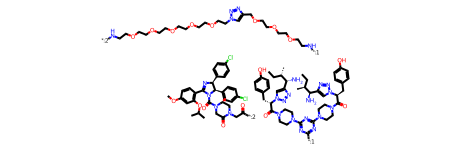

--------------------------------------------------------------------------------
[PROTAC-DB; PROTACpedia] MW=1963.2  e3_evidence=none  n_filters=3  rank=0.971
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


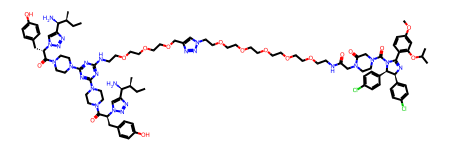

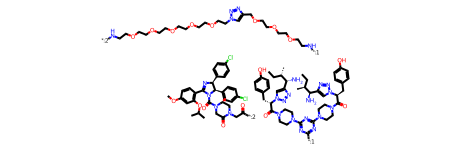

--------------------------------------------------------------------------------
[PROTAC-DB; PROTACpedia] MW=1963.2  e3_evidence=none  n_filters=3  rank=0.971
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


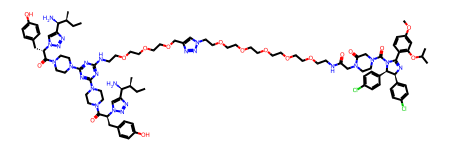

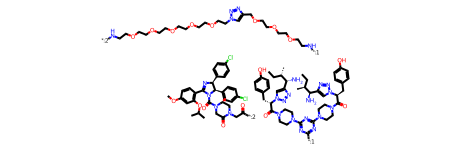

--------------------------------------------------------------------------------
[PROTAC-DB] MW=1875.0  e3_evidence=none  n_filters=3  rank=0.971
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


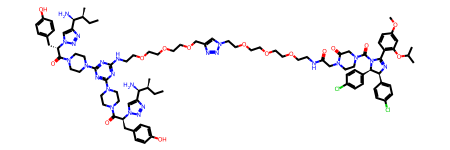

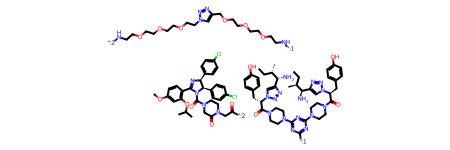

--------------------------------------------------------------------------------
[TPDdb] MW=360.4  e3_evidence=none  n_filters=3  rank=0.971
CC(C)[C@@H](C(=O)N1C[C@](C)(O)C[C@H]1C(=O)O)N1Cc2ccccc2C1=O


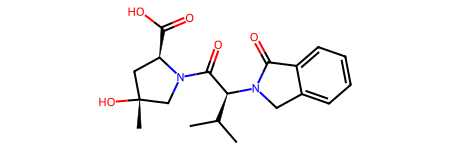

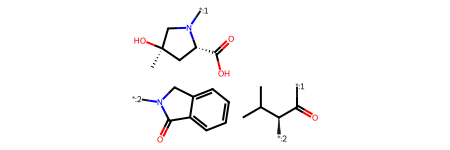

--------------------------------------------------------------------------------
[PROTACpedia] MW=382.3  e3_evidence=none  n_filters=3  rank=0.970
O=C(NC1CCNCC1)c1n[nH]cc1NC(=O)c1c(Cl)cccc1Cl


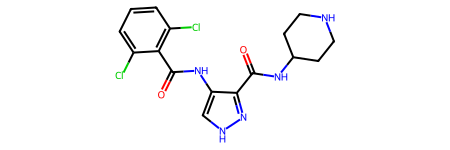

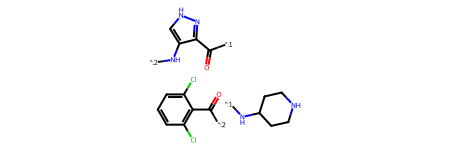

--------------------------------------------------------------------------------
[TPDdb] MW=394.5  e3_evidence=none  n_filters=3  rank=0.970
CCC(=O)N1CCC(C(=O)Nc2ncc(SCc3ncc(C)o3)s2)CC1


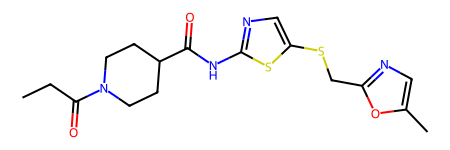

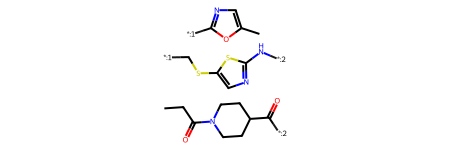

--------------------------------------------------------------------------------
[TPDdb] MW=1041.9  e3_evidence=none  n_filters=3  rank=0.969
COc1cc(N2CCC(CN3CC[C@H](c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1P(C)(C)=O)OCCCCn1cc-2cn1


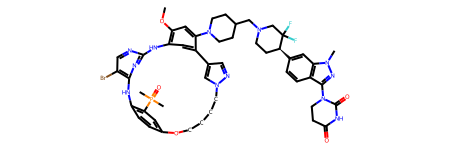

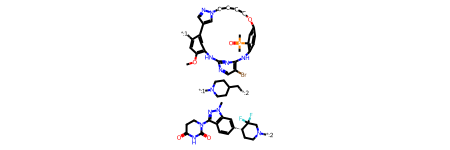

--------------------------------------------------------------------------------
[TPDdb] MW=1041.9  e3_evidence=none  n_filters=3  rank=0.969
COc1cc(N2CCC(CN3CC[C@@H](c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1P(C)(C)=O)OCCCCn1cc-2cn1


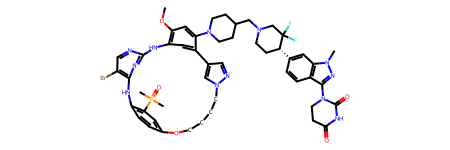

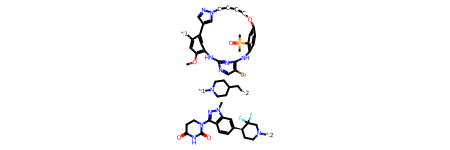

--------------------------------------------------------------------------------
[TPDdb] MW=1059.9  e3_evidence=none  n_filters=3  rank=0.968
COc1cc(N2CCC(CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1cc(F)c(cc1P(C)(C)=O)OCCCCn1cc-2cn1


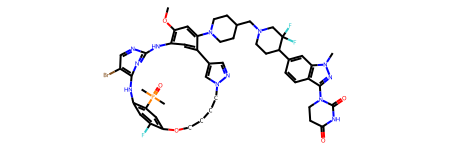

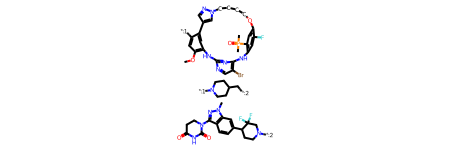

--------------------------------------------------------------------------------
[TPDdb] MW=1041.9  e3_evidence=none  n_filters=3  rank=0.968
COc1cc(N2CCC(CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1P(C)(C)=O)OCCCCn1cc-2cn1


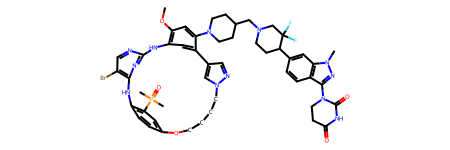

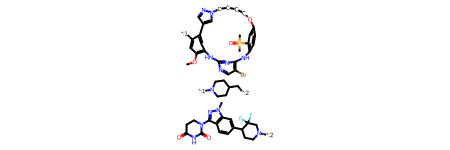

--------------------------------------------------------------------------------
[TPDdb] MW=1325.5  e3_evidence=none  n_filters=3  rank=0.963
CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OCCNC(=O)c3cccc4c3OB(c3ccc(C(=O)NCCN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=NC(c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)cc3)O4)ccc2-n2c(C)nnc21


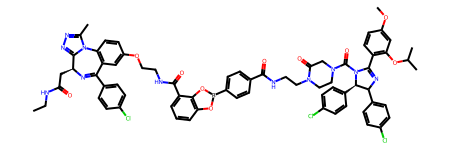

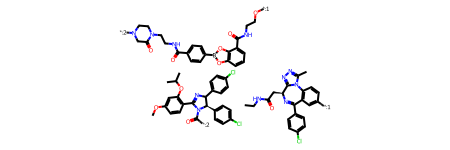

--------------------------------------------------------------------------------
[TPDdb] MW=1037.1  e3_evidence=none  n_filters=3  rank=0.960
COc1cc(N2CCC(CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1


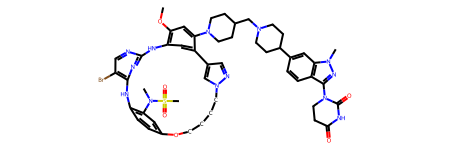

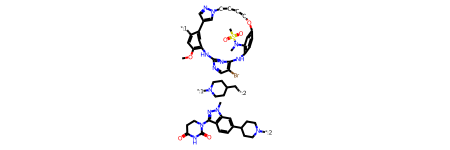

--------------------------------------------------------------------------------
[TPDdb] MW=1038.0  e3_evidence=none  n_filters=3  rank=0.960
COc1cc(N2CCC(CN3CCN(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1


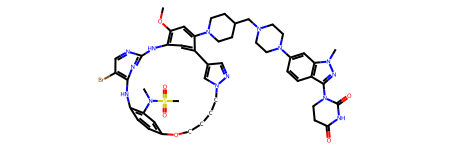

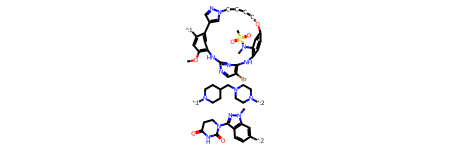

--------------------------------------------------------------------------------
[TPDdb] MW=1105.0  e3_evidence=none  n_filters=3  rank=0.960
CN(c1cc2ccc1Nc1nc(ncc1Br)Nc1cc(F)c(N3CCC(O)(CC(=O)N4CCC(c5ccc6c(N7CCC(=O)NC7=O)nn(C)c6c5)C(F)(F)C4)CC3)c(c1)-c1cnn(c1)CCCCO2)S(C)(=O)=O


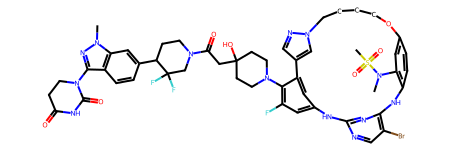

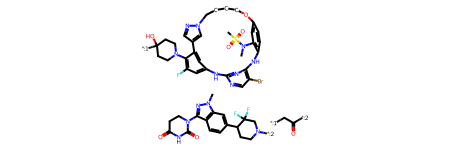

--------------------------------------------------------------------------------
[TPDdb] MW=1590.7  e3_evidence=wh_curated_representative  n_filters=3  rank=0.959
C=C1CCC(N2C(=O)c3cccc(NCCNC(=O)COCC(C)(COCCOCCOCCOCCNC(=O)C[C@@H]4N=C(c5ccc(Cl)cc5)c5c(sc(C)c5C)-n5c(C)nnc54)COCCOCCOCCOCCNC(=O)C[C@@H]4N=C(c5ccc(Cl)cc5)c5c(sc(C)c5C)-n5c(C)nnc54)c3C2=O)C(=O)N1


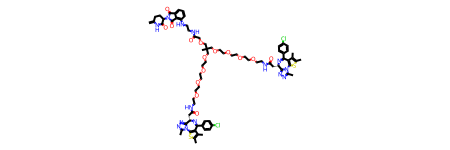

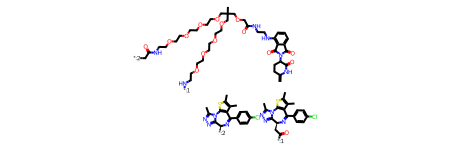

--------------------------------------------------------------------------------
[TPDdb] MW=1090.0  e3_evidence=none  n_filters=3  rank=0.959
CN(c1cc2ccc1Nc1nc(ncc1Br)Nc1cc(F)c(N3CCN(C(=O)CN4CCC(c5ccc6c(N7CCC(=O)NC7=O)nn(C)c6c5)C(F)(F)C4)CC3)c(c1)-c1cnn(c1)CCCCO2)S(C)(=O)=O


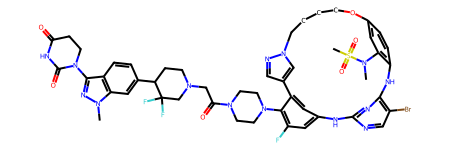

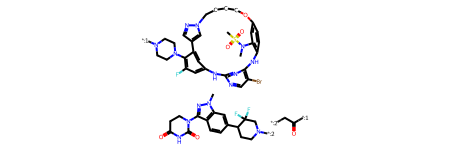

--------------------------------------------------------------------------------
[TPDdb] MW=1104.0  e3_evidence=none  n_filters=3  rank=0.959
CN(c1cc2ccc1Nc1nc(ncc1Br)Nc1cc(F)c(N3CCN(C(=O)CN4CCC(c5ccc6c(N7CCC(=O)NC7=O)nn(C)c6c5)C(F)(F)C4)CC3)c(c1)-c1cnn(c1)CCCCCO2)S(C)(=O)=O


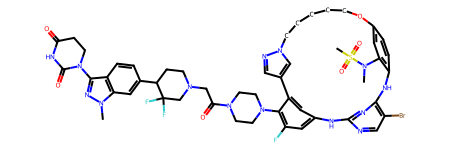

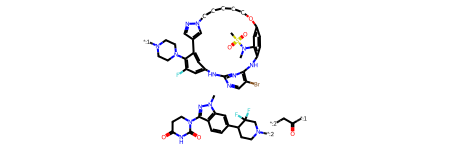

--------------------------------------------------------------------------------
[TPDdb] MW=1091.0  e3_evidence=none  n_filters=3  rank=0.958
COc1cc(N2CCC(CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1cc(F)c(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1


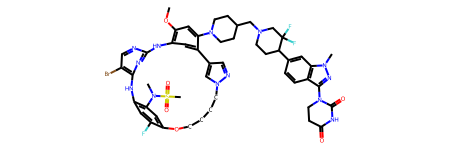

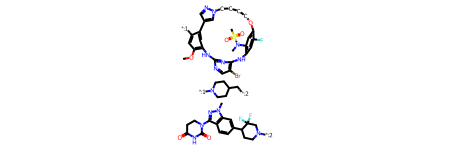

--------------------------------------------------------------------------------
[TPDdb] MW=1116.1  e3_evidence=none  n_filters=3  rank=0.958
COc1cc(N2CCN(C(=O)CN3CCC(c4ccc5c(N6CCC(=O)NC6=O)nn(C)c5c4)C(F)(F)C3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCCn1cc-2cn1


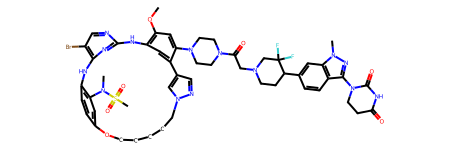

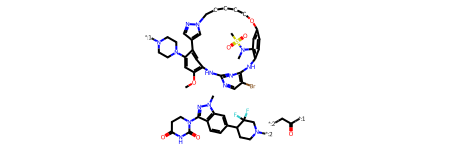

--------------------------------------------------------------------------------


In [99]:
from rdkit.Chem.Draw import IPythonConsole  # noqa: F401  (inline molecule rendering)

def to_mol(smi):
    return Chem.MolFromSmiles(smi) if isinstance(smi, str) else None

flagged = df[df['is_probable_non_protac']].sort_values('non_protac_rank', ascending=False)
print(f'{len(flagged)} probable non-PROTACs; showing the 20 highest-ranked (most suspect):')
for _, row in flagged.head(20).iterrows():
    print(f'[{row["Database"]}] MW={row["protac_mw"]}  e3_evidence={row["e3_evidence"]}  '
          f'n_filters={row["n_filters"]}  rank={row["non_protac_rank"]:.3f}')
    print(row['SMILES'])
    display(to_mol(row['SMILES']))            # intact molecule (judged)
    display(to_mol(row['default_pred_n0']))   # its split (context only)
    print('-' * 80)

Contrast: 12 random high-confidence PROTACs (kept, known E3 ligand), for calibration:
[TPDdb] MW=937.0  e3_evidence=CRBN;e3_curated_representative


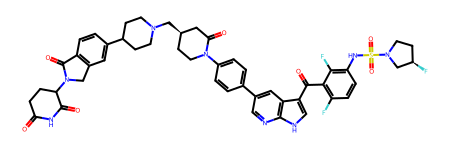

--------------------------------------------------------------------------------
[PROTAC-DB] MW=922.0  e3_evidence=CRBN;e3_curated_representative


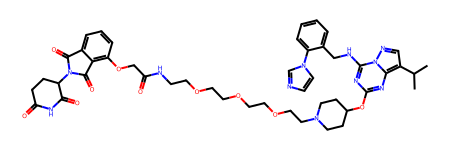

--------------------------------------------------------------------------------
[PROTAC-DB] MW=1063.3  e3_evidence=VHL;wh_curated_representative


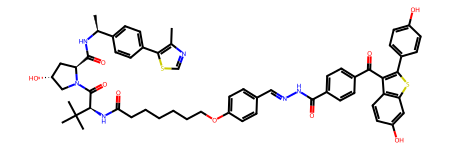

--------------------------------------------------------------------------------
[PROTAC-DB] MW=870.0  e3_evidence=CRBN;e3_curated_representative


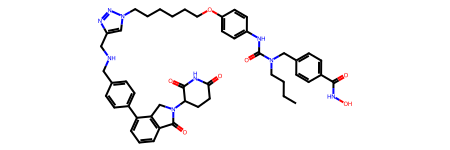

--------------------------------------------------------------------------------
[TPDdb] MW=902.6  e3_evidence=VHL;wh_curated_representative


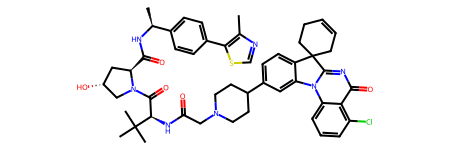

--------------------------------------------------------------------------------
[TPDdb] MW=1145.8  e3_evidence=VHL;wh_curated_representative


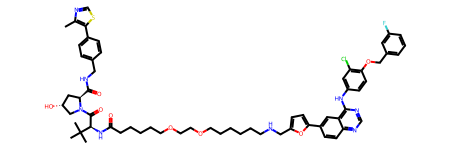

--------------------------------------------------------------------------------
[TPDdb] MW=614.1  e3_evidence=CRBN


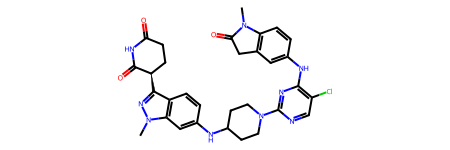

--------------------------------------------------------------------------------
[TPDdb] MW=927.2  e3_evidence=VHL;wh_curated_representative


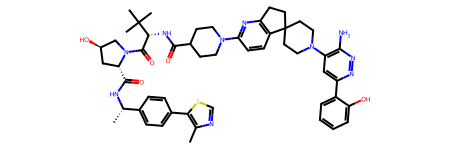

--------------------------------------------------------------------------------
[TPDdb] MW=861.4  e3_evidence=CRBN;e3_curated_representative


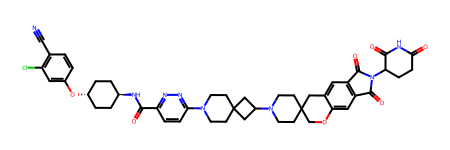

--------------------------------------------------------------------------------
[PROTAC-DB] MW=830.3  e3_evidence=CRBN;e3_curated_representative;wh_curated_representative


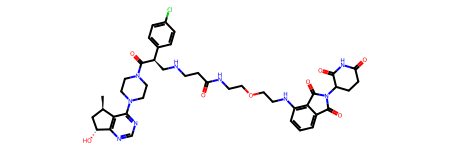

--------------------------------------------------------------------------------
[TPDdb] MW=929.5  e3_evidence=CRBN;e3_curated_representative


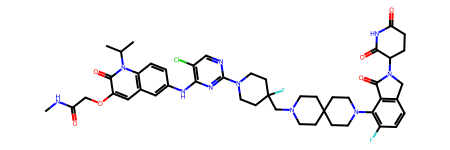

--------------------------------------------------------------------------------
[PROTACpedia] MW=801.9  e3_evidence=CRBN;e3_curated_representative


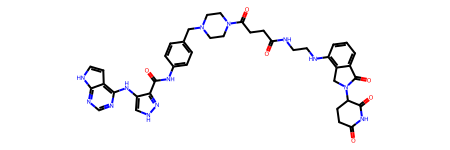

--------------------------------------------------------------------------------


In [100]:
kept_conf = df[df['is_good_quality'] & df['has_known_e3']]
print('Contrast: 12 random high-confidence PROTACs (kept, known E3 ligand), for calibration:')
for _, row in kept_conf.sample(n=12, random_state=RANDOM_STATE).iterrows():
    print(f'[{row["Database"]}] MW={row["protac_mw"]}  e3_evidence={row["e3_evidence"]}')
    display(to_mol(row['SMILES']))
    print('-' * 80)

In [101]:
# plot_df(df[df['is_probable_non_protac']])

In [102]:
df[df['is_probable_non_protac']].groupby('Database')['is_probable_non_protac'].describe()
display(df[df['flag_no_known_e3']].groupby('Database')['is_probable_non_protac'].describe())
display(df[df['flag_rule']].groupby('Database')['is_probable_non_protac'].describe())
display(df[df['flag_isoforest']].groupby('Database')['is_probable_non_protac'].describe())

,count,unique,top,freq
Database,,,,
PROTAC-DB,43,1,True,43
PROTAC-DB; PROTACpedia,12,1,True,12
PROTAC-DB; TPDdb,1,1,True,1
PROTACpedia,10,1,True,10
TPDdb,2961,1,True,2961


,count,unique,top,freq
Database,,,,
PROTAC-DB,236,1,True,236
PROTAC-DB; PROTACpedia,255,1,True,255
PROTAC-DB; PROTACpedia; TPDdb,17,1,True,17
PROTAC-DB; TPDdb,6,1,True,6
PROTACpedia,77,1,True,77
TPDdb,2196,1,True,2196


,count,unique,top,freq
Database,,,,
PROTAC-DB,246,1,True,246
PROTAC-DB; PROTACpedia,149,1,True,149
PROTAC-DB; TPDdb,5,1,True,5
PROTACpedia,56,1,True,56
PROTACpedia; TPDdb,1,1,True,1
TPDdb,2164,1,True,2164


In [103]:
# plot_df(df[(df['is_probable_non_protac']) & (df['Database'].str.contains('PROTAC-DB'))].sample(frac=1))

## Save to file

In [104]:
df.to_csv('../smiles_with_filters.csv', index=False)

## Using this

- **`df['is_probable_non_protac']`** is the recommended filter: molecules that both **lack a known
  E3-ligand chemotype** and are **structurally anomalous** (rule-based or IsolationForest). Drop
  these; keep `df['is_good_quality']`.
- **`df['non_protac_rank']`** gives a continuous ranking for a harder/softer cut than the intersection
  (see the threshold-sensitivity table); `df['n_signals']` (0–3) gives a simple consensus level.
- **`df['has_known_e3']` / `df['e3_evidence']`** are useful on their own: *presence* of a known E3
  ligand is strong positive evidence a molecule is a real PROTAC. Its *absence* is only a candidate
  flag — novel-E3 PROTACs land here too, which is exactly why absence is combined with an anomaly
  signal rather than used alone.